In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm, tnrange, tqdm_notebook
import time
import sys
import struct
import os
import tqdm

from scipy.optimize import curve_fit

%matplotlib widget
import ipywidgets as widgets
import traitlets
from IPython.display import display
from ipywidgets import widgets
from tkinter import Tk, filedialog
from IPython.display import clear_output
import io
from ipywidgets import interact, interactive, fixed, interact_manual
from ipywidgets import AppLayout, Button, Layout

from alive_progress import alive_bar
import time

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"

In [9]:
!python "./Read_PHU.py" "../../Lab Work/TB-TCSPC/LLF 5 minutes.phu" "../../Lab Work/TB-TCSPC/LLF 5 minutes.txt"

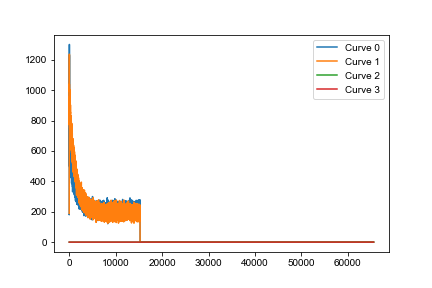

In [10]:
# Initialize variables
curveIndices = []
histogramDataByCurve = []
currentCurveData = []

# Read the file
with open('../../Lab Work/TB-TCSPC/LLF 30 minutes.txt', 'r') as file:
    for line in file:
        line = line.strip()
        if line.startswith("Curve#"):
            # Get the curve index from the line
            curveIndex = int(line.split()[1])
            curveIndices.append(curveIndex)
            if currentCurveData:
                histogramDataByCurve.append(currentCurveData)
                currentCurveData = []
        elif line.startswith("Counts"):
            # Start reading histogram data
            for histogramData in file:
                histogramData = histogramData.strip()
                if histogramData and not histogramData.startswith("-"):
                    try:
                        currentCurveData.append(int(histogramData))
                    except ValueError:
                        print("Invalid histogram data:", histogramData)
                else:
                    break

# Append the last curve's data to the list
histogramDataByCurve.append(currentCurveData)

x = np.arange(0, 4096, 1)

fig1, ax1 = plt.subplots()

# Print the histogram data for each curve
for i, curveData in enumerate(histogramDataByCurve):
    # print("Curve #", curveIndices[i])
    # print(curveData)
    # print()
    ax1.plot(curveData, label="Curve %d" % curveIndices[i])
 
ax1.set_title("Histogram Data")   
ax1.set_xlabel("Time (ns)")
ax1.set_ylabel("Counts") 
plt.legend()
plt.show()